# Testing rbf with wasserstein loss

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import numpy as np
import logging
import sys
from pathlib import Path
import torch
from IPython.display import display

import matplotlib.pyplot as plt
import diffmeshopt.opt2d.evaluation as evaluation
from diffmeshopt.opt2d import vis
from pprint import pprint
import diffmeshopt.opt2d.debug as debug_module
import diffmeshopt.opt2d.trainer as trainer_module
import diffmeshopt.opt2d.config as config_module
import diffmeshopt.opt2d.notebook_utils as nbutils
from diffmeshopt.opt2d.enums import DataLossType, RefinerType, RegularizerType
import diffmeshopt.opt2d.log_builder as logbuilder

debug_module.DEBUG = True

# Configure logging to stdout
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)

In [3]:
# Define paths
dataset_path = Path("../data/2d_training_data_perturbations.pkl")  # Adjust if needed
output_dir = "../output/verification_test_5A/rbf/"
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = nbutils.load_perturbation_dataset(dataset_path)
print(f"Using device: {device}")

Using device: cpu


In [ ]:
GOAL = "Test optimization with RBF refiner and Wasserstein loss on perturbed data."
NOTEBOOK = "perturbed_search_rbf_s3p5_wasserstein.ipynb"

LOG_PATH = "/Users/saugat/code/diffmeshopt/EXPERIMENT_LOG.md"

In [5]:
refiner_props = nbutils.DEFAULT_RBF_REFINER_PROPS
refiner_props = refiner_props.replace(
    data_loss_type=DataLossType.BIGAUSSIAN_WASSERSTEIN,
    initial_regularization_weights={
        "contour_laplacian": 0.0,
        "edge_length": 0.0,
        "normal_consistency": 0.0,
        "tangential_laplacian": 0.0,
        "contour_anchor": 0.0,
        "rbf_weight_decay": 0.001,
    },
    shape_loss_weight=0.1,
)

template_props = nbutils.DEFAULT_TEMPLATE_PROPS
template_props = template_props.replace(smoothness_window_size=5, min_peak_ratio=3.0)

In [ ]:
seed = 145
(trainer, run_id, run_dir, image_t, contour_t, gt_contour_t, template_model, seed) = (
    nbutils.create_trainer_from_manual_config(
        dataset=dataset,
        output_dir=output_dir,
        device=device,
        refiner_kind=RefinerType.RBF,
        refiner_props=refiner_props,
        template_props=template_props,
        run_id=debug_module.make_run_id("rbf_wasserstein"),
        seed=seed,
    )
)

Computing contour metrics between GT and initial contour...
{'mean_dist': 4.831218719482422, 'hausdorff_dist': 10.816654205322266, 'p95_dist': 8.5440034866333}
2026-07-28 16:18:40,666 - INFO - Creating template model: bspline
2026-07-28 16:18:40,666 - INFO - Initializing ContourLoss
Shape loss weight tensor(0.1000)
2026-07-28 16:18:40,668 - INFO - Auto-configured RBF sigma: 44.23 (avg spacing: 22.11)
2026-07-28 16:18:40,669 - INFO - Output directory set to: ../output/verification_test_5A/rbf/20260728-1618_rbf_wasserstein/2026-07-28_16-18-40


/Users/saugat/code/diffmeshopt/diffmeshopt/opt2d/refiner.py:929: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("sigma", torch.tensor(sigma))
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [13]:
trainer.fit(10000)

2026-07-28 16:18:46,126 - INFO - Starting fit for 10000 steps.


/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/saugat/code/diffmeshopt/output/verification_test_5A/rbf/20260728-1618_rbf_wasserstein/2026-07-28_16-18-40 exists and is not empty.
/Users/saugat/code/diffmeshopt/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


2026-07-28 16:19:54,296 - INFO - Final state saved to ../output/verification_test_5A/rbf/20260728-1618_rbf_wasserstein/2026-07-28_16-18-40/final.pkl


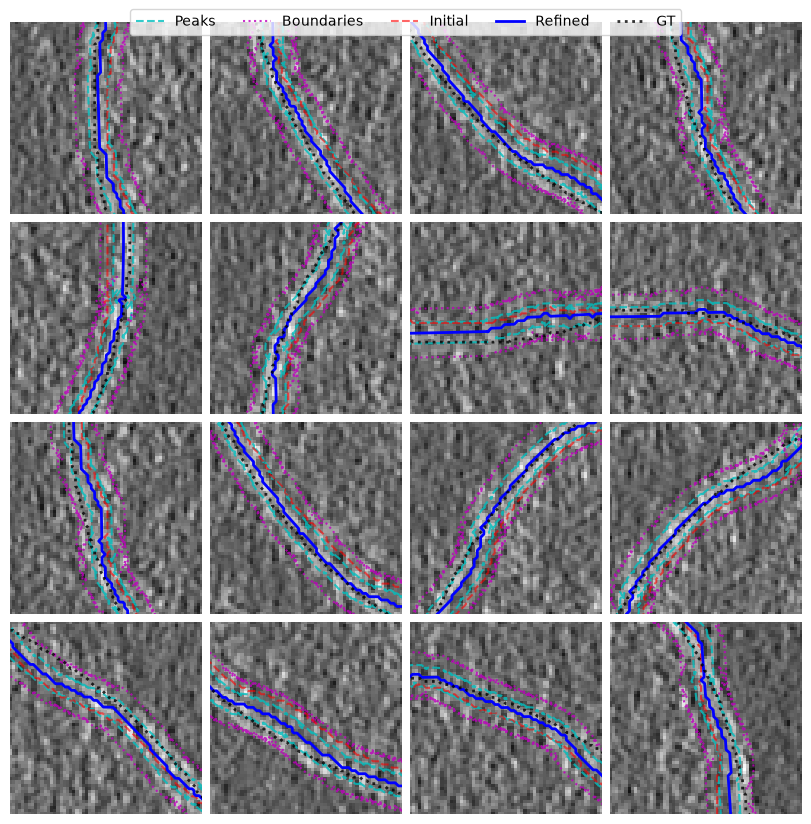

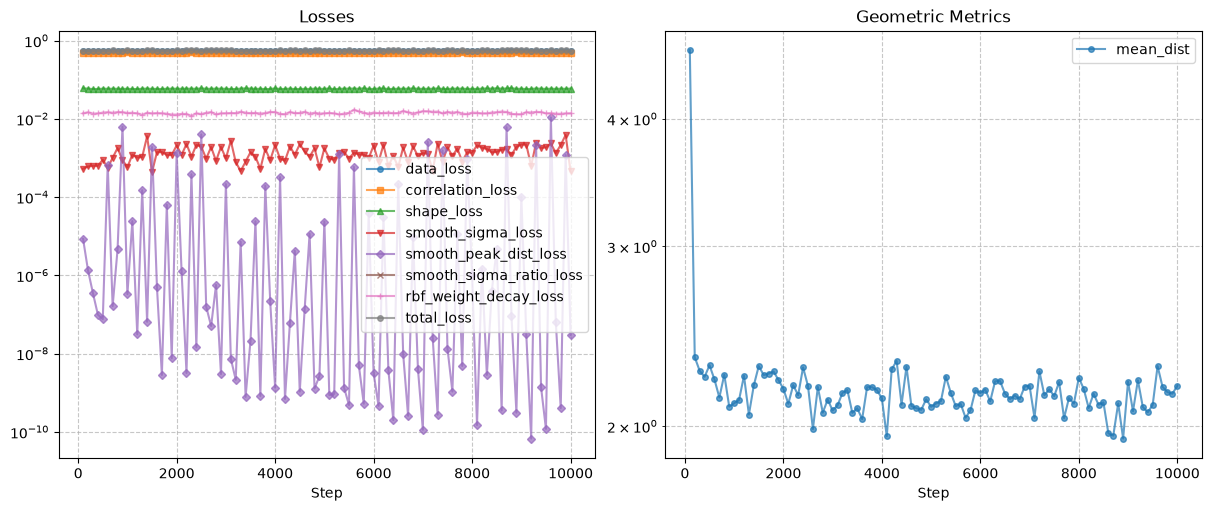

Chamfer from init 2.9587178230285645
Mean Peak Dist: 6.17, Mean Sigma1: 2.06, Mean Sigma2: 2.06


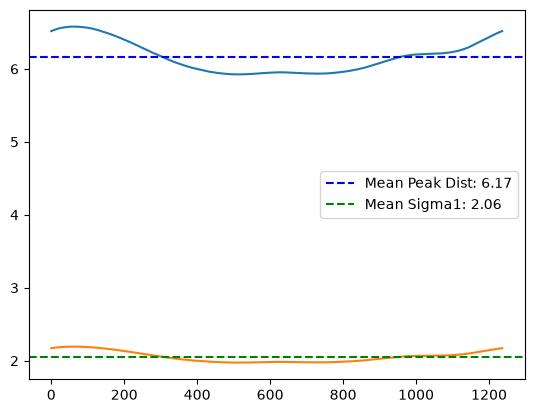

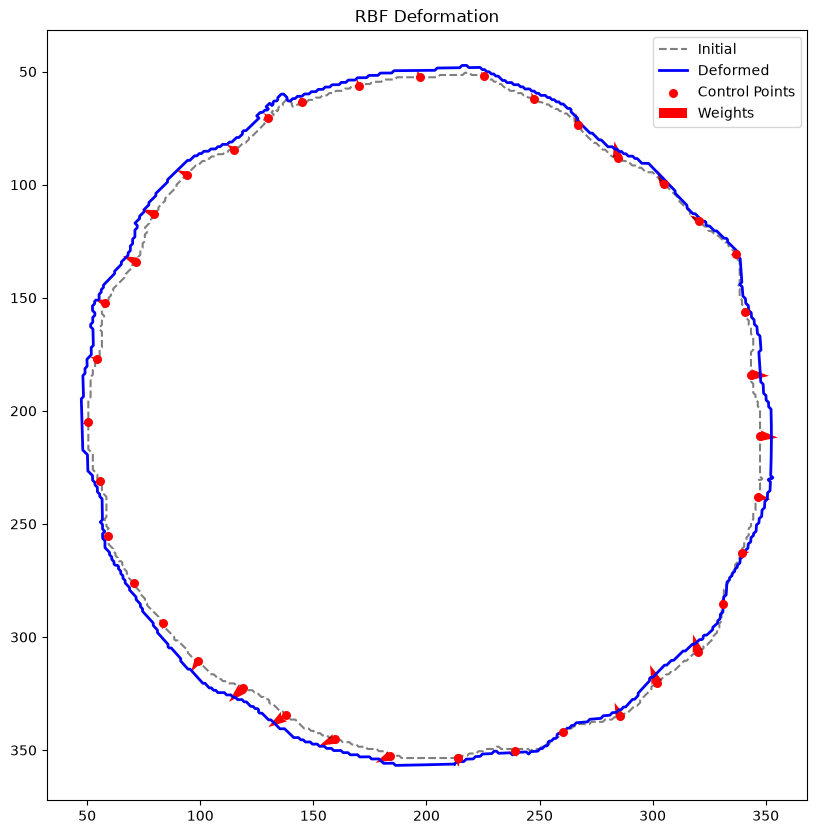

THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporarily using L2 norm for averaging template profiles for visualization.
THIS IS A DEBUG SETTING AND NEEDS TO BE CHANGED. Context:
Temporary setting for profile norm calculations. Not sure how it works with L1 vs L2.


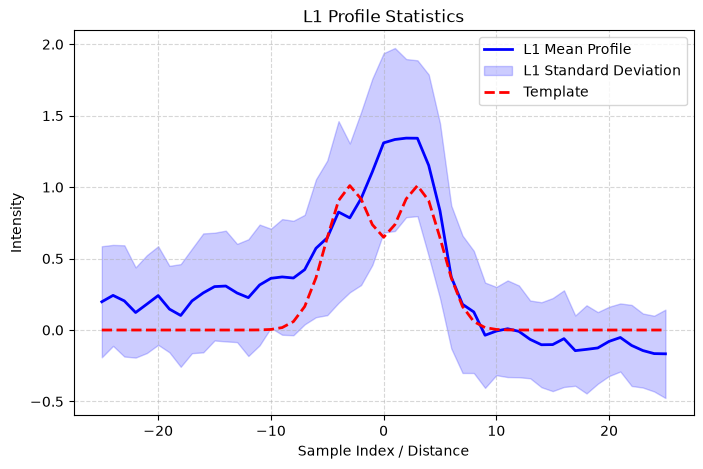

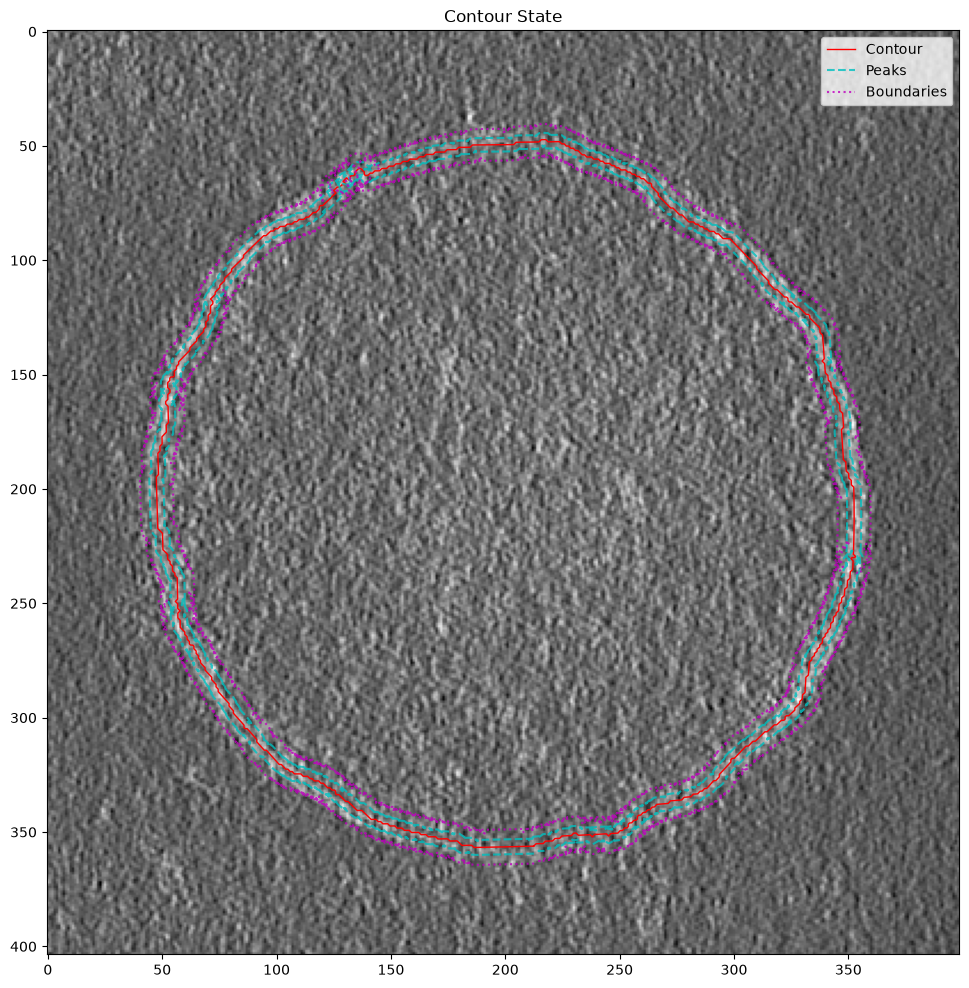

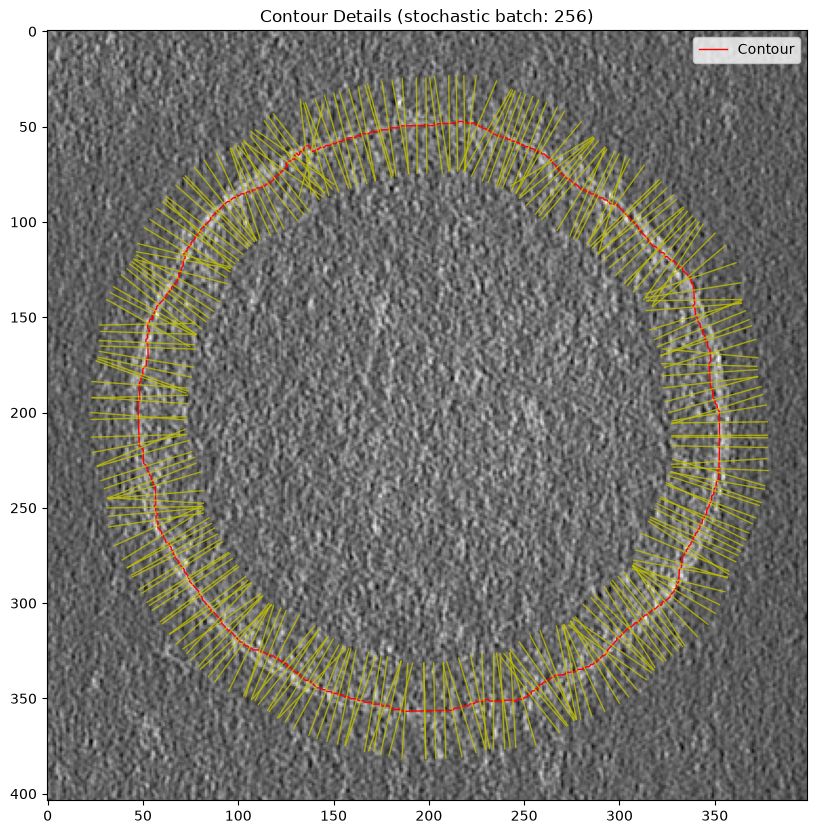

In [15]:
metrics_from_init, template_diagnostics = nbutils.analyze_trainer_results(
    trainer, contour_t, image_t
)

In [ ]:
VISUAL_CHECKS = {
    "contour_bump": "Still a bump at presumably the location where the contour is closed.",
    "template": "Template looks single gaussian.",
    "fits": "Fitting doesn't seem great.",
}

INTERPRETATION = [
    "Wasserstein loss is not helping the alignment like I would have hoped.",
    "Template fitting needs work. One option is to make the contour anchor harder.",
    "Cyclic contour needs more testing.",
]

NEXT_ACTION = ["Test longer cyclic contour."]

STATUS = "complete"

tmp_log = logbuilder.create_experiment_log_entry_from_trainer(
    trainer,
    run_id,
    initial_metrics=metrics_from_init,
    template_diagnostics=template_diagnostics,
    notebook_script=NOTEBOOK,
    goal=GOAL,
    visual_checks=VISUAL_CHECKS,
    interpretation=INTERPRETATION,
    next_action=NEXT_ACTION,
    status=STATUS,
    device=device,
    seeds=seed,
)

logbuilder.append_experiment_log()